Trabajo practico

In [2]:
import pandas as pd
Matriculas = pd.read_excel('14_MATRICULAS_ED_SUPERIOR_LOS_LAGOS_2021.xlsx')
Matriculas

,ID,GENERO,EDAD,RANGO EDAD,AÑO INGRESO,SEMESTRE INGRESO,TIPO DE INSTITUCION,NOMBRE DE INSTITUCION,ACREDITACION INSTITUCIONAL,PERIODO DE ACREDITACION,...,NIVEL CARRERA,AREA CONOCIMIENTO,DURACION PLAN DE ESTUDIO (SEMESTRES),DURACION PROCESO TITULACION (SEMESTRES),DURACION TOTAL CARRERA (SEMESTRES),VALOR MATRICULA (PESOS),VALOR ARANCEL (PESOS),REGION SEDE,PROVINCIA SEDE,COMUNA SEDE
0,45,Femenino,22,20 a 24,2018,Primer semestre,Universidades Privadas,UNIVERSIDAD SANTO TOMAS,ACREDITADA,31/03/2021 AL 31/03/2025,...,Carreras Profesionales,Ciencias Sociales,10,0,10,134000,3154000,Los Lagos,Osorno,Osorno
1,49,Femenino,54,40 y mas,2019,Primer semestre,Universidades CRUCH,UNIVERSIDAD DE LOS LAGOS,ACREDITADA,12/12/2016 AL 12/12/2020,...,Carreras Tecnicas,Educacion,5,0,5,102000,1721000,Los Lagos,Chiloe,Castro
2,51,Femenino,25,25 a 29,2020,Primer semestre,Centros de Formacion Tecnica,CFT INACAP,ACREDITADA,05/01/2018 AL 05/01/2025,...,Carreras Tecnicas,Administracion y Comercio,4,0,4,220000,1864000,Los Lagos,Llanquihue,Puerto Montt
3,75,Masculino,23,20 a 24,2019,Primer semestre,Universidades CRUCH,UNIVERSIDAD DE LOS LAGOS,ACREDITADA,12/12/2016 AL 12/12/2020,...,Carreras Tecnicas,Educacion,5,0,5,102000,1721000,Los Lagos,Llanquihue,Puerto Montt
4,121,Femenino,19,15 a 19,2020,Primer semestre,Universidades Privadas,UNIVERSIDAD SAN SEBASTIAN,ACREDITADA,13/09/2016 AL 13/09/2021,...,Carreras Profesionales,Administracion y Comercio,10,1,10,185300,4182600,Los Lagos,Llanquihue,Puerto Montt
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34367,1048439,Femenino,46,40 y mas,2020,Primer semestre,Universidades CRUCH,UNIVERSIDAD DE LOS LAGOS,ACREDITADA,12/12/2016 AL 12/12/2020,...,Carreras Tecnicas,Educacion,5,0,5,102000,1721000,Los Lagos,Llanquihue,Puerto Montt
34368,1048443,Masculino,29,25 a 29,2021,Primer semestre,Centros de Formacion Tecnica,CFT INACAP,ACREDITADA,05/01/2018 AL 05/01/2025,...,Carreras Tecnicas,Administracion y Comercio,4,0,4,220000,1864000,Los Lagos,Osorno,Osorno
34369,1048456,Masculino,29,25 a 29,2020,Primer semestre,Institutos Profesionales,IP DUOC UC,ACREDITADA,26/08/2017 AL 26/08/2024,...,Carreras Tecnicas,Tecnologia,5,1,5,176000,2160000,Los Lagos,Llanquihue,Puerto Montt
34370,1048465,Masculino,26,25 a 29,2019,Primer semestre,Universidades CRUCH,UNIVERSIDAD DE LOS LAGOS,ACREDITADA,12/12/2016 AL 12/12/2020,...,Carreras Tecnicas,Educacion,5,0,5,102000,1721000,Los Lagos,Chiloe,Castro


In [3]:
Matriculas.tail(1)

,ID,GENERO,EDAD,RANGO EDAD,AÑO INGRESO,SEMESTRE INGRESO,TIPO DE INSTITUCION,NOMBRE DE INSTITUCION,ACREDITACION INSTITUCIONAL,PERIODO DE ACREDITACION,...,NIVEL CARRERA,AREA CONOCIMIENTO,DURACION PLAN DE ESTUDIO (SEMESTRES),DURACION PROCESO TITULACION (SEMESTRES),DURACION TOTAL CARRERA (SEMESTRES),VALOR MATRICULA (PESOS),VALOR ARANCEL (PESOS),REGION SEDE,PROVINCIA SEDE,COMUNA SEDE
34371,1048473,Masculino,19,15 a 19,2020,Primer semestre,Universidades CRUCH,UNIVERSIDAD DE LOS LAGOS,ACREDITADA,12/12/2016 AL 12/12/2020,...,Carreras Tecnicas,Tecnologia,5,0,5,102000,1766000,Los Lagos,Llanquihue,Puerto Montt


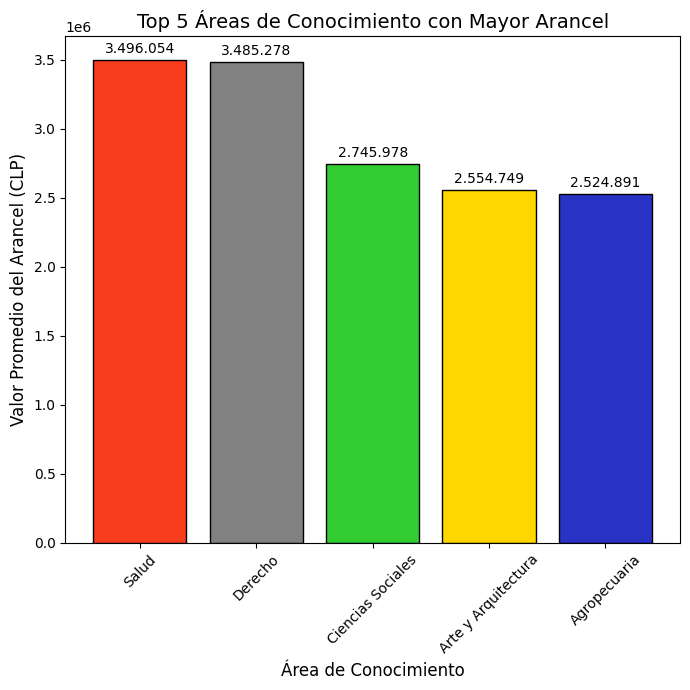

In [42]:
import matplotlib.pyplot as plt
import numpy as np

# Agrupar por área de conocimiento y calcular el promedio del arancel
TABLA_ARANCEL = Matriculas.groupby('AREA CONOCIMIENTO')['VALOR ARANCEL (PESOS)'].mean().sort_values(ascending=False).head(5)

CATEGORIAS = TABLA_ARANCEL.index
F = TABLA_ARANCEL.values

# Formatear montos con punto como separador de miles
ETIQUETAS = [format(valor, ',.0f').replace(',', '.') for valor in F]

# Colores personalizados para cada barra
COLORES = ["#F73D1C", "#818181", '#32CD32', '#FFD700', "#2833C5"]  # rojo coral, azul acero, verde lima, dorado, violeta

# Gráfico
fig, ax = plt.subplots(figsize=(7,7))
BARRAS = ax.bar(CATEGORIAS, F, color=COLORES, edgecolor='black')

# Personalización
ax.set_title('Top 5 Áreas de Conocimiento con Mayor Arancel', fontsize=14)
ax.set_xlabel('Área de Conocimiento', fontsize=12)
ax.set_ylabel('Valor Promedio del Arancel (CLP)', fontsize=12)
ax.bar_label(BARRAS, labels=ETIQUETAS, padding=3, fontsize=10)
plt.xticks(rotation=45, fontsize=10)
plt.tight_layout()
plt.show()

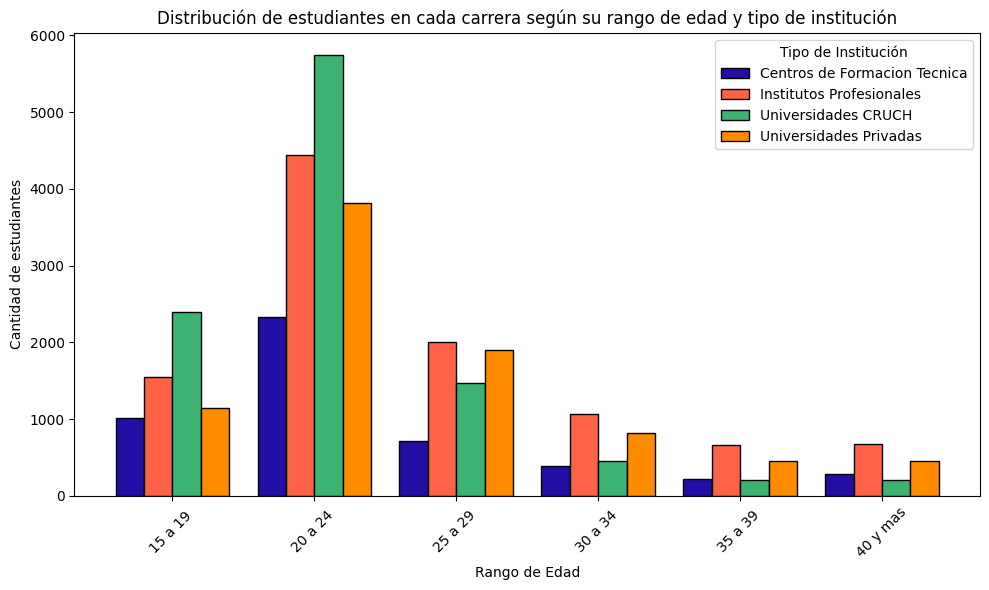

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Agrupar por RANGO EDAD y TIPO DE INSTITUCION
tabla_rangos = Matriculas.groupby(['RANGO EDAD', 'TIPO DE INSTITUCION']).size().unstack(fill_value=0)
tabla_rangos_orden = tabla_rangos.sort_index()

# Variables
Categorias = tabla_rangos_orden.index
tipos = tabla_rangos_orden.columns
x = np.arange(len(Categorias))
ancho = 0.8 / len(tipos)

# Nueva paleta de colores
# Nueva paleta de colores: tonos profesionales y diferenciables
colores = ['#6A5ACD', '#FF6347', '#3CB371', '#FF8C00', '#20B2AA', '#8B0000']  # azul violeta, rojo coral, verde medio, naranja oscuro, verde azulado, rojo oscuro  # índigo, fucsia, turquesa, dorado, verde, carmesí

# Gráfico
fig, ax = plt.subplots(figsize=(10,6))

for i, tipo in enumerate(tipos):
    color = colores[i % len(colores)]  # Cicla colores si hay más tipos
    ax.bar(x + i*ancho, tabla_rangos_orden[tipo], width=ancho, label=tipo, edgecolor='black', color=color)

# Personalización
ax.set_title('Distribución de estudiantes en cada carrera según su rango de edad y tipo de institución')
ax.set_xlabel('Rango de Edad')
ax.set_ylabel('Cantidad de estudiantes')
ax.set_xticks(x + ancho*(len(tipos)-1)/2)
ax.set_xticklabels(Categorias, rotation=45)
ax.legend(title='Tipo de Institución')
plt.tight_layout()
plt.show()

#  Item 1:

Poblacion: Todos los estudiantes de educacion que estan registrados en la region de los lagos en el año 2021

Muestra: Los 34.373 estudiantes que fueron matriculados en el año 2021

# INSTRUCCIONES:

Variable 1 Culitativa Nominal : GENERO

Tabla frecuencia   f y h

Grafico a elección // interpretación 2 aspectos relevantes

Medida de tendencia central : Moda // calcular e  interpretar

In [3]:
frecuencia_absoluta_1 = Matriculas.groupby('GENERO').size() 
muestra_1 = Matriculas.shape[0] 
frecuencia_relativa_1 = round(frecuencia_absoluta_1 / muestra_1 * 100, 1) 
tabla_genero = pd.DataFrame({ 
    'Frecuencia absoluta (f)': frecuencia_absoluta_1, 
    'Frecuencia relativa (%)': frecuencia_relativa_1 }) 
tabla_genero

,Frecuencia absoluta (f),Frecuencia relativa (%)
GENERO,,
Femenino,20395,59.3
Masculino,13977,40.7


In [18]:
edades = Matriculas.groupby('RANGO EDAD').size()

tabla_edades = pd.DataFrame({
    'Frecuencia absoluta':edades,
    'Frecuencia relativa':round((edades / 34372 )* 100, 1)
})

tabla_edades

tabla_edades_orden = tabla_edades.sort_values('Frecuencia absoluta', ascending=False)
tabla_edades_orden

,Frecuencia absoluta,Frecuencia relativa
RANGO EDAD,,
20 a 24,16332,47.5
15 a 19,6093,17.7
25 a 29,6084,17.7
30 a 34,2715,7.9
40 y mas,1615,4.7
35 a 39,1533,4.5


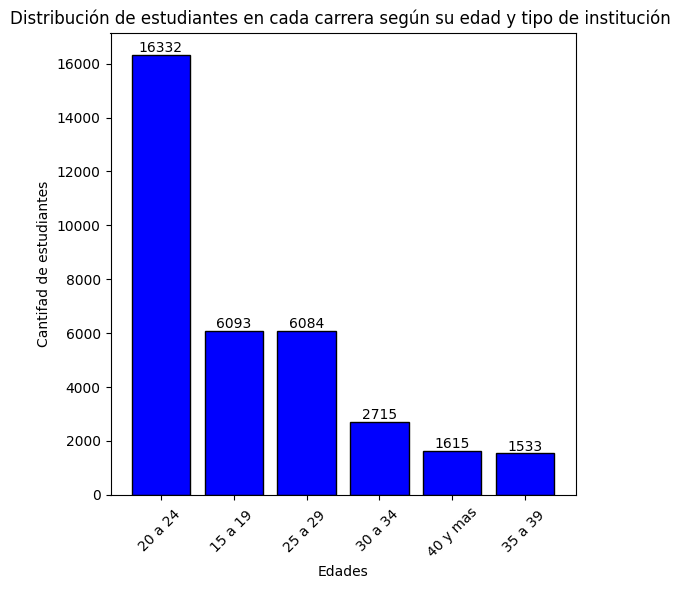

In [22]:
#Gráfico de barras (Columnas)

#Considerar que "tabla" es el nombre de la tabla de frecuencias construida

# Importar bibliotecas o librerías
import matplotlib.pyplot as plt
import numpy as np

#Variables
Categorias = tabla_edades_orden.index
f = tabla_edades_orden['Frecuencia absoluta']   #Considerar que "Frecuencia" es el tipo de frecuencia a graficar

#Gráfico
fig, ax = plt.subplots(figsize = (6,6))
barras = ax.bar(Categorias, f, color = 'b', edgecolor ='black') #Los colores son de libre elección

#Personalización
ax.set_title('Distribución de estudiantes en cada carrera según su edad y tipo de institución ')
ax.set_xlabel('Edades')
ax.set_ylabel('Cantifad de estudiantes')
ax.bar_label(barras)
plt.xticks(rotation=45) #Rota en 45° las categorías para evitar la superposición
plt.show()

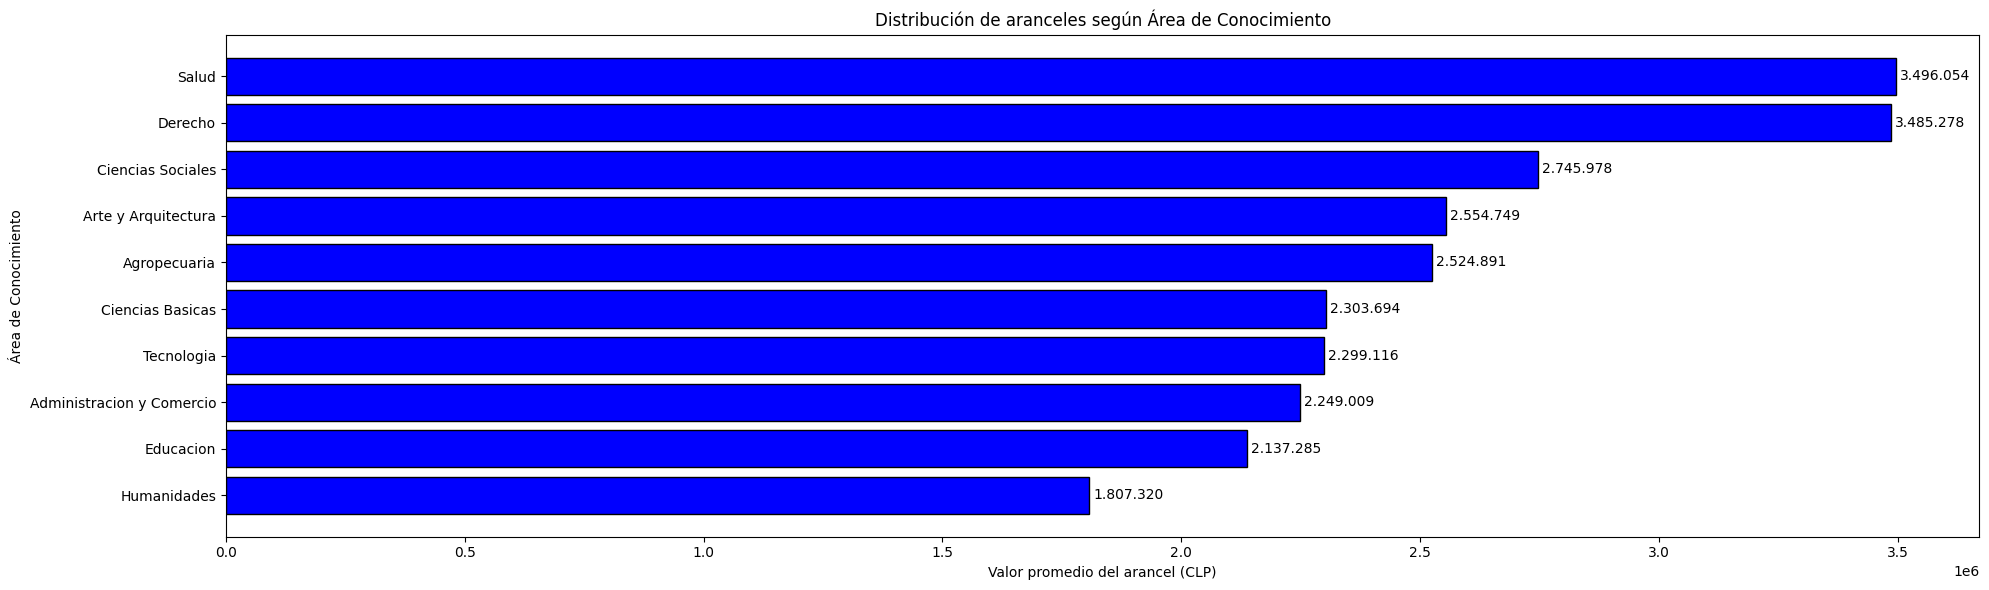

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Agrupar por área de conocimiento y calcular el promedio del arancel
tabla_arancel = Matriculas.groupby('AREA CONOCIMIENTO')['VALOR ARANCEL (PESOS)'].mean().sort_values(ascending=True)

Categorias = tabla_arancel.index
f = tabla_arancel.values

fig, ax = plt.subplots(figsize=(20,6))
barras = ax.barh(Categorias, f, color='blue', edgecolor='black')

ax.set_title('Distribución de aranceles según Área de Conocimiento')
ax.set_xlabel('Valor promedio del arancel (CLP)')
ax.set_ylabel('Área de Conocimiento')

# Etiquetas con separador de miles usando punto
etiquetas = [format(valor, ',.0f').replace(',', '.') for valor in f]
ax.bar_label(barras, labels=etiquetas, padding=3)

plt.tight_layout()
plt.show()

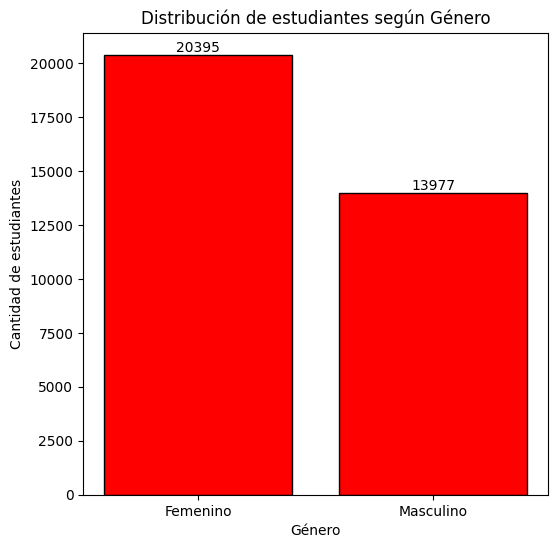

In [4]:
import matplotlib.pyplot as plt
import numpy as np

Categorias = tabla_genero.index
f = tabla_genero['Frecuencia absoluta (f)']  
fig, ax = plt.subplots(figsize=(6,6))
barras = ax.bar(Categorias, f, color='red', edgecolor='black')  

ax.set_title('Distribución de estudiantes según Género')
ax.set_xlabel('Género')
ax.set_ylabel('Cantidad de estudiantes')
ax.bar_label(barras)
plt.xticks(rotation=0)  
plt.show()


In [14]:
moda_genero = Matriculas['GENERO'].mode()[0]
print(f"La moda es '{moda_genero[0]}', lo que significa que el género más frecuente entre los estudiantes matriculados es {moda_genero}")


La moda es 'F', lo que significa que el género más frecuente entre los estudiantes matriculados es Femenino


Variable 2 Cualitativa Ordinal: NIVEL CARRERA

Tabla de frecuencia f y h 

Gráfico a elección  // interpretación 2 aspectos relevantes

Medida de tendencia central : Moda  // calcular e  interpretar

In [6]:
frecuencia_absoluta_2 = Matriculas.groupby('NIVEL CARRERA').size()
muestra_2 = Matriculas.shape[0]
frecuencia_relativa_2 = round(frecuencia_absoluta_2 / muestra_2 * 100, 1)

tabla_nivel = pd.DataFrame({
    'Frecuencia absoluta (f)': frecuencia_absoluta_2,
    'Frecuencia relativa (%)': frecuencia_relativa_2
})

tabla_nivel


,Frecuencia absoluta (f),Frecuencia relativa (%)
NIVEL CARRERA,,
Carreras Profesionales,21685,63.1
Carreras Tecnicas,11797,34.3
Doctorado,24,0.1
Magister,636,1.9
Postitulo,230,0.7


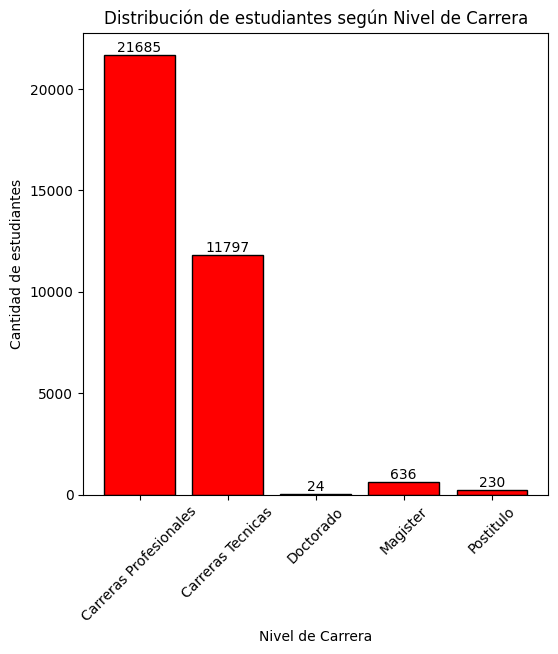

In [7]:
Categorias = tabla_nivel.index
f = tabla_nivel['Frecuencia absoluta (f)']

fig, ax = plt.subplots(figsize=(6,6))
barras = ax.bar(Categorias, f, color='red', edgecolor='black')

ax.set_title('Distribución de estudiantes según Nivel de Carrera')
ax.set_xlabel('Nivel de Carrera')
ax.set_ylabel('Cantidad de estudiantes')
ax.bar_label(barras)
plt.xticks(rotation=45)  
plt.show()


In [23]:
moda_nivel = Matriculas['NIVEL CARRERA'].mode()[0]
print(f"La moda de la variable NIVEL CARRERA es '{moda_nivel}', lo que significa que la mayoría de los estudiantes se encuentran en este nivel.")


La moda de la variable NIVEL CARRERA es 'Carreras Profesionales', lo que significa que la mayoría de los estudiantes se encuentran en este nivel.


In [ ]:
## Variable 3 Cuantitativa discreta:  EDAD
## Tabla de frecuencia f, h , F y H 
## Gráfico a elección   //  interpretación 2 aspectos relevantes
## Medida de tendencia central : Media-Moda- Mediana  // calcular e  interpretar
## Percentiles 25 50 75   // calcular e  interpretar
## Coeficiente de variación  Homogéneo y Heterogéneo   // calcular e  interpretar

In [23]:
intervalos_edad = Matriculas.groupby('EDAD',observed=True).size()

intervalos_edad

EDAD
17       1
18     951
19    5141
20    2073
21    3970
22    3705
23    3079
24    3505
25     870
26    1582
27    1267
28    1062
29    1303
30     322
31     653
32     577
33     505
34     658
35     188
36     317
37     369
38     273
39     386
40     101
41     190
42     200
43     172
44     142
45     121
46     118
47      97
48      82
49      81
50      64
51      57
52      35
53      38
54      22
55      23
56      18
57      18
58      12
59       6
60       2
61       4
62       4
63       2
65       3
67       1
71       1
72       1
dtype: int64

In [24]:
Matriculas['Intervalos'] = pd.cut(Matriculas['EDAD'], bins=10, include_lowest=True, precision=0)
intervalos_edad = Matriculas.groupby('Intervalos', observed=True).size()

tabla_edad = pd.DataFrame({
    'Frecuencia absoluta (f)':intervalos_edad,
    'Frecuencia absoluta acumulada (F)':intervalos_edad.cumsum(),
    'Frecuencia relativa (h)': (intervalos_edad/34372 * 100).round(2),
    'Frecuencia relativa acumulada (H)':((intervalos_edad/34372 *100).cumsum()).round(2)
})

tabla_edad

,Frecuencia absoluta (f),Frecuencia absoluta acumulada (F),Frecuencia relativa (h),Frecuencia relativa acumulada (H)
Intervalos,,,,
"(16.0, 22.0]",15841,15841,46.09,46.09
"(22.0, 28.0]",11365,27206,33.06,79.15
"(28.0, 34.0]",3360,30566,9.78,88.93
"(34.0, 39.0]",2191,32757,6.37,95.30
"(39.0, 44.0]",805,33562,2.34,97.64
"(44.0, 50.0]",563,34125,1.64,99.28
"(50.0, 56.0]",175,34300,0.51,99.79
"(56.0, 61.0]",60,34360,0.17,99.97
"(61.0, 66.0]",9,34369,0.03,99.99


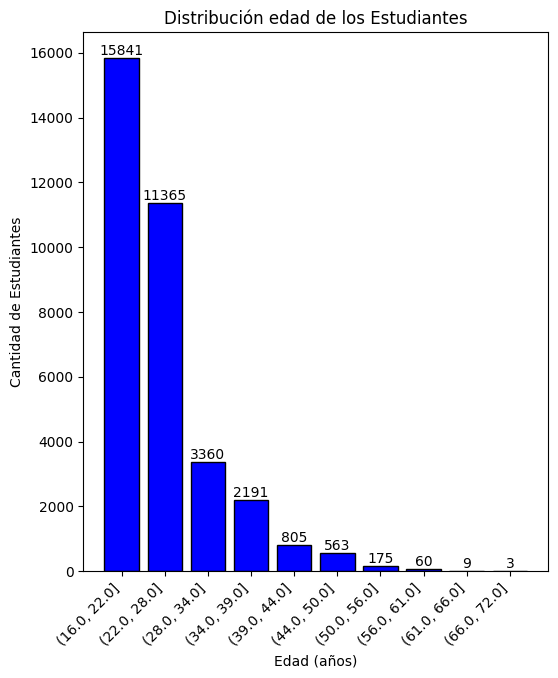

In [26]:
import matplotlib.pyplot as plt
import numpy as np

categorias = tabla_edad.index
f= tabla_edad['Frecuencia absoluta (f)']   

fig, ax = plt.subplots(figsize = (6,7))
histograma= ax.bar(categorias.astype(str), f, color = 'b', edgecolor = 'black') 


ax.set_title('Distribución edad de los Estudiantes')
ax.set_xlabel('Edad (años)')
ax.set_ylabel('Cantidad de Estudiantes')
ax.bar_label(histograma)
plt.xticks(rotation=45, ha = 'right') 
plt.show()

# 1 
La mayor parte de los estudiantes en la region de Los Lagos se concentra en los rangos de edad entre 16 y 22 años, con más de 15.000 personas. Esto es correcto ya que es la edad típica de ingreso a educación superior y refleja una población estudiantil mayoritariamente joven 

# 2
A partir de los 28 años de edad, la cantidad de estudiantes en la region de Los Lagos baja drásticamente, esto sugiere que la educación superior en edades mayores es poco frecuente pero no inexistente

In [28]:
media_edad = Matriculas['EDAD'].mean()
media_edad

np.float64(24.991679273827533)

La edad promedio de los estudiantes de la region de Los Lagos es de 25 años

In [29]:
moda_edad = Matriculas['EDAD'].mode()
moda_edad

0    19
Name: EDAD, dtype: int64

La edad que más se repite entre los estudiantes de la region de Los Lagos es de 19 años

In [30]:
mediana_edad = Matriculas['EDAD'].median()
mediana_edad

np.float64(23.0)

La mitad de la edad de los estudiantes de la region de Los Lagos es de 23 años

In [31]:
percentil_25 = Matriculas['EDAD'].quantile(0.25)
percentil_25

np.float64(21.0)

El 25% de los estudiantes de la region de Los Lagos es menor o igual a 21 años de edad

In [23]:
percentil_50 = Matriculas['EDAD'].quantile(0.50)
percentil_50

np.float64(23.0)

El 50% de los estudiantes de la region de Los Lagos es menor o igual a 23 años de edad

In [24]:
percentil_75 = Matriculas['EDAD'].quantile(0.75)
percentil_75

np.float64(27.0)

El 75% de los estudiantes de la region de Los Lagos es menor o igual a 27 años de edad

In [171]:
Matriculas.describe().round()

,ID,EDAD,AÑO INGRESO,AÑOS DE ACREDITACION,DURACION PLAN DE ESTUDIO (SEMESTRES),DURACION PROCESO TITULACION (SEMESTRES),DURACION TOTAL CARRERA (SEMESTRES),VALOR MATRICULA (PESOS),VALOR ARANCEL (PESOS)
count,34372.0,34372.0,34372.0,33844.0,34372.0,34372.0,34372.0,34372.0,34372.0
mean,521573.0,25.0,2019.0,5.0,8.0,0.0,8.0,162787.0,2687242.0
std,302819.0,7.0,2.0,1.0,3.0,1.0,3.0,92469.0,1168140.0
min,45.0,17.0,1995.0,2.0,1.0,0.0,1.0,0.0,0.0
25%,258221.0,21.0,2018.0,4.0,5.0,0.0,5.0,134000.0,1790000.0
50%,519136.0,23.0,2020.0,5.0,8.0,0.0,8.0,175000.0,2160000.0
75%,783417.0,27.0,2021.0,5.0,10.0,1.0,10.0,190000.0,3757000.0
max,1048473.0,72.0,2021.0,7.0,14.0,2.0,14.0,1400000.0,7725000.0


Desviación : 7

In [32]:
cv = 7/25*100
cv

28.000000000000004

La edad presenta un comportamiento heterogeneo, ya que el Coeficiente de Variación de la edad es de 28%

In [ ]:
## Variable 4 Cuantitativa Continua : VALOR ARANCEL 
## Tabla de frecuencia f, h , F y H 
## Gráfico Histograma // Interpretar 3 aspectos relevantes: intervalos mayor y menor frecuencia y el rango.
## Medida de tendencia central : Media-Moda- Mediana  // calcular e  interpretar
## Percentiles 25 50 75   // calcular e  interpretar
## Coeficiente de variación Homogéneo y Heterogéneo  // calcular e  interpretar

In [ ]:
intervalos_arancel = Matriculas.groupby('VALOR ARANCEL (PESOS)',observed=True).size()

intervalos_arancel

In [3]:
Matriculas['Intervalos'] = pd.cut(Matriculas['VALOR ARANCEL (PESOS)'], bins=10, include_lowest=True, precision=0)
intervalos_arancel = Matriculas.groupby('Intervalos', observed=True).size()

tabla_arancel = pd.DataFrame({
    'Frecuencia absoluta (f)':intervalos_arancel,
    'Frecuencia absoluta acumulada (F)':intervalos_arancel.cumsum(),
    'Frecuencia relativa (h)': (intervalos_arancel/34372 * 100).round(2),
    'Frecuencia relativa acumulada (H)':((intervalos_arancel/34372 *100).cumsum()).round(2)
})

tabla_arancel

,Frecuencia absoluta (f),Frecuencia absoluta acumulada (F),Frecuencia relativa (h),Frecuencia relativa acumulada (H)
Intervalos,,,,
"(-7726.0, 772500.0]",25,25,0.07,0.07
"(772500.0, 1545000.0]",1518,1543,4.42,4.49
"(1545000.0, 2317500.0]",17582,19125,51.15,55.64
"(2317500.0, 3090000.0]",3513,22638,10.22,65.86
"(3090000.0, 3862500.0]",5668,28306,16.49,82.35
"(3862500.0, 4635000.0]",5199,33505,15.13,97.48
"(4635000.0, 5407500.0]",17,33522,0.05,97.53
"(5407500.0, 6180000.0]",63,33585,0.18,97.71
"(6180000.0, 6952500.0]",298,33883,0.87,98.58


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

categorias = tabla_arancel.index
f= tabla_arancel['Frecuencia absoluta (f)']   

fig, ax = plt.subplots(figsize = (6,7))
histograma= ax.bar(categorias.astype(str), f, color = 'b', edgecolor = 'black') 


ax.set_title('Distribución arancel de los Estudiantes')
ax.set_xlabel('Valor Arancel (pesos)')
ax.set_ylabel('Cantidad de Estudiantes')
ax.bar_label(histograma)
plt.xticks(rotation=45, ha = 'right') 
plt.show()

# 1
El intervalo de  $1.545.000 y $2.317.500 concentra la mayor cantidad de estudiantes de la region de Los Lagos con una cantidad de 17.582 estudiantes

# 2
En el tramo de $1.545.000 hasta $2.317.500 pagan 17 582 estudiantes, mientras que en el intervalo de $4.635.000 hasta $5.407.500 lo hacen solo 17, en el rango central hay mil veces más alumnos que en el extremo alto


# 3
Los aranceles van desde $0 hasta $7.725.000, existe una gran amplitud en el arancel más económico y el más caro, lo que demuestra la gran diversidad de costos en la oferta academica 

In [175]:
media =Matriculas['VALOR ARANCEL (PESOS)'].mean()
media

np.float64(2687242.445013383)

In [12]:
moda = Matriculas['VALOR ARANCEL (PESOS)'].mode()
moda

0    3869000
Name: VALOR ARANCEL (PESOS), dtype: int64

In [177]:
mediana = Matriculas['VALOR ARANCEL (PESOS)'].median()
mediana

np.float64(2160000.0)

Media : En promedio, cada estudiante paga alrededor de $2.687.242 de arancel
Moda : La mitad de los estudiantes paga hasta $2.160.000 y la otr mitad paga más de esa cifra
Mediana : El valor de arancel más frecuente es $3.869.000, aunque no coincide con el tramo de mayor frecuencia del histograma, revela que muchos programas fijos cobran ese importe

In [9]:
percentil_25 = Matriculas['VALOR ARANCEL (PESOS)'].quantile(0.25)
percentil_25

np.float64(1790000.0)

In [179]:
percentil_50 = Matriculas['VALOR ARANCEL (PESOS)'].quantile(0.50)
percentil_50

np.float64(2160000.0)

In [10]:
percentil_75 = Matriculas['VALOR ARANCEL (PESOS)'].quantile(0.75)
percentil_75

np.float64(3757000.0)

P25: El 25% de los estudiantes de la region de Los Lagos paga un arancel igual o menor a $1.790.000
P50: El 50% de los estudiantes de la region de Los Lagos paga hasta $2.160.000 y el otro 50% paga más que esa cifra
P75 El 75% de los estudiantes de la region de Los Lagos paga un arancel igual o menor a $3.757.000

In [181]:
Matriculas.describe().round()

,ID,EDAD,AÑO INGRESO,AÑOS DE ACREDITACION,DURACION PLAN DE ESTUDIO (SEMESTRES),DURACION PROCESO TITULACION (SEMESTRES),DURACION TOTAL CARRERA (SEMESTRES),VALOR MATRICULA (PESOS),VALOR ARANCEL (PESOS)
count,34372.0,34372.0,34372.0,33844.0,34372.0,34372.0,34372.0,34372.0,34372.0
mean,521573.0,25.0,2019.0,5.0,8.0,0.0,8.0,162787.0,2687242.0
std,302819.0,7.0,2.0,1.0,3.0,1.0,3.0,92469.0,1168140.0
min,45.0,17.0,1995.0,2.0,1.0,0.0,1.0,0.0,0.0
25%,258221.0,21.0,2018.0,4.0,5.0,0.0,5.0,134000.0,1790000.0
50%,519136.0,23.0,2020.0,5.0,8.0,0.0,8.0,175000.0,2160000.0
75%,783417.0,27.0,2021.0,5.0,10.0,1.0,10.0,190000.0,3757000.0
max,1048473.0,72.0,2021.0,7.0,14.0,2.0,14.0,1400000.0,7725000.0


Desviacion : 1168140

In [182]:
cv = 1168140/2687242*100
cv

43.469847523966955

La dispercion de los aranceles es del 43.5% en relación a su valor promedio, al ser mayor que 30%, este Coeficiente de Variación se clasifica como heterogéneo

# Item 2

## ¿Hay áreas del conocimiento donde las carreras sean más caras? Expliquen qué criterio diseñaron para responder la pregunta.

Si, segun los datos, hay carreras con aranceles mas caros que otras, la media muestra un valor de arancel de 2.687.247,
la mediana es 2.160.000 y el percentil 75 es 3.757.000, lo cual significa que todas las carreras cuyo arancel supera ese valor estan por encima del 75% de la matricula, por lo tanto, son mas caras,
en general las areas de salud y algunas ingenierias son las mas caras dado que tienen mas años de estudio y labs especializados.



mostrar grafico

## ¿Qué influencia tiene la edad en el tipo de institución a la que ingresan los estudiantes?

La media de edad es de 25 años, la moda es 19 y la mediana es de 23, el 75% de los estudiantes tiene hasta los 28 años, lo cual confirma que la poblacion es mayoritariamente joven,
esto influye en el tipo de institucion, dado que los estudiantes mas jovenes (hasta los 22 años) tienden a ingresar principalmente a universidades,
mientras que los mayores de 25 años estan concentrados en institutos profecriosionales y centros de formacion tecnica, ya que la duracion de las carreras
es mas corta y se adaptan mejor a sus necesidades como trabajar y estudiar al mismo tiempo.

## ¿Hay carreras cuyo arancel sea sustantivamente más caro que la mayoría de los aranceles? ¿Qué explicación pueden encontrar? Consideren qué variables de la base de datos los puede ayudar y el contexto de la región que les tocó trabajar.

Si, hay carreras con un arancel mas caro que la mayoria, dado que el percentil 75 alcanza los 3.757.000 pesos, y todas las carreras sobre ese valor,
estan ubicadas entre el grupo mas costoso, esto pasa principalmente en areas como medicina, odontologia y algunas ingenierias, que requieren una mayor cantidad de años de estudio y labs especializados,
adneas se imparten mayormente en universidades privadas, en la region de los lagos esta diferencia se acentua debido a la menor precencia de universidades
tradicionales, lo cual obliga a muchos estudiantes a optar por las instituciones privadas que cuentan con aranceles mas alto.


